In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

def load_data():
  from google.colab import drive
  drive.mount('/content/drive')
  dataset_path = "/content/drive/MyDrive/ALL2upload"

  images = []
  filenames = []
  labels = []

  for label in ["Malignant", "Benign"]:
    folder_path = os.path.join(dataset_path, label)

    for filename in os.listdir(folder_path):
      image_path = os.path.join(folder_path, filename)
      image = cv2.imread(image_path) #converts to array

      if image is None:
        continue

      images.append(image)
      filenames.append(filename)

      if label == 'Malignant':
        labels.append(1)
      else:
        labels.append(0)

  return images,labels,filenames

def preprocess(images_list):
  #hsv range
  converted_images=[]
  lower = np.array([118, 35, 204])
  upper = np.array([143, 230, 255])

  #preprocessing steps
  for im in images_list:
    hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv,lower,upper)
    kernel = np.ones((3,3),dtype=np.uint8)
    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,kernel)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernel)
    result = cv2.bitwise_and(im,im,mask=mask)
    white = np.full(im.shape, 255, dtype=np.uint8)
    inverted_mask = cv2.bitwise_not(mask)
    cutout = cv2.bitwise_and(white,white, mask=inverted_mask)
    final_output = cv2.bitwise_or(cutout,result)
    converted_images.append(final_output)

  return converted_images

def traintest_classweight_normalize(images_list,labels_list,seed):
  #Train test split
  x = np.array(images_list)
  y = np.array(labels_list)
  x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=seed)

  #Class weights
  weights = compute_class_weight(
      class_weight = 'balanced',
      classes= np.unique(y_train),
      y=y_train
  )

  class_weights={
      0: weights[0],
      1: weights[1]
  }

  #Normalize
  x_test = x_test/255
  x_train = x_train/255

  return x_train, y_train, x_test, y_test, class_weights

def train_model(x_train, y_train, class_weights):
  #CNN
  model = Sequential([
      Input(shape = (224,224,3)),

      Conv2D(32,(3,3), activation='relu', name='conv1'),
      MaxPooling2D((2,2)),

      Conv2D(64,(3,3), activation='relu', name='conv2'),
      MaxPooling2D((2,2)),

      Conv2D(128,(3,3), activation='relu', name='conv3'),
      MaxPooling2D((2,2)),

      Flatten(),
      Dropout(0.25),
      Dense(128, activation='relu'),
      Dense(1, activation='sigmoid')
  ])

  #Configure training
  optimizer = AdamW(learning_rate=1e-4)

  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics = ['accuracy']
  )

  #Train
  model.fit(x_train, y_train, epochs=15, class_weight=class_weights,verbose=0)

  return model

def evaluate_model(model, x_test, y_test):
  #Test & print accuracy
  loss, accuracy = model.evaluate(x_test,y_test)
  print(f'Accuracy: {accuracy}')
  y_pred = model.predict(x_test, verbose=0)
  y_pred_binary = y_pred.round()

  #Confusion matrix
  cm = confusion_matrix(y_test,y_pred_binary)
  tn, fp, fn, tp = cm.ravel()
  #print(f'TN: {tn} FP: {fp} FN: {fn} TP: {tp}') in case I want to change display type
  print("TN:", tn)
  print("FP:", fp)
  print("FN:", fn)
  print("TP:", tp)

  #Classification report
  report = classification_report(y_test, y_pred_binary, output_dict=True)
  print(f"Overall Accuracy: {report['accuracy']:.3f}")
  print()

  print('Benign Stats')
  print(f'Precision: {report["0"]["precision"]:.3f}')
  print(f'Recall: {report["0"]["recall"]:.3f}')
  print(f'F1: {report["0"]["f1-score"]:.3f}')
  print()

  print('Malignant Stats')
  print(f'Precision: {report["1"]["precision"]:.3f}')
  print(f'Recall: {report["1"]["recall"]:.3f}')
  print(f'F1: {report["1"]["f1-score"]:.3f}')
  print()

def grad_cam(model,x_test, random_grad_idx):
  image = x_test[random_grad_idx]
  image = np.expand_dims(image, axis=0)
  last_conv_layer = model.get_layer('conv3')

  # Get the final Dense layer weights
  final_layer = model.layers[-1]
  weights, bias = final_layer.get_weights()

  grad_model = tf.keras.models.Model(
    inputs = model.inputs,
    outputs=[
        last_conv_layer.output,
        model.layers[-2].output
    ])

  with tf.GradientTape() as tape:
    last_conv_output, dense_features = grad_model([image])
    logit = tf.matmul(dense_features, weights) + bias

  grads = tape.gradient(logit, last_conv_output)
  importance_weights = tf.reduce_mean(grads, axis=(0,1,2))
  last_conv_output = last_conv_output[0]
  heatmap = last_conv_output * importance_weights
  heatmap = tf.reduce_sum(heatmap, axis=-1)
  heatmap = tf.maximum(heatmap, 0)

  max_value = tf.reduce_max(heatmap) # prevents division by zero
  if max_value > 0:
    heatmap = heatmap / max_value

  heatmap = heatmap.numpy()
  heatmap = cv2.resize(heatmap, (224, 224))
  heatmap = np.uint8(255 * heatmap)

  return heatmap

def display_visual(heatmap, random_grad_idx, x_test, y_test, model):
  print('Displaying one sample image')

  test_image = x_test[random_grad_idx]
  original_image = (test_image * 255).astype(np.uint8)

  color_heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
  superimposed = cv2.addWeighted(original_image, 0.6, color_heatmap, 0.4, 0)

  fig, axes = plt.subplots(1, 4, figsize=(16, 4))
  axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
  axes[0].set_title("Original")
  axes[1].imshow(heatmap, cmap='gray')
  axes[1].set_title("Gray Map")
  axes[2].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
  axes[2].set_title("Grad-CAM overlay")
  axes[3].imshow(heatmap, cmap="jet")
  axes[3].set_title("Raw heatmap")

  plt.tight_layout()
  plt.show()

  #To see if it was correct or not
  image = np.expand_dims(test_image, axis=0)
  prediction = model.predict(image, verbose=0)

  print("True label:", y_test[random_grad_idx])
  print("Raw prediction:", prediction[0][0])
  rounded = prediction[0][0]
  rounded = rounded.round()
  print(f'Rounded result: {rounded}')
  print(f'Index: {random_grad_idx}')
  print()

Mounted at /content/drive
| PIPELINE 1 |
Pipeline 1 results with seed = 42
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9495 - loss: 0.1456
Accuracy: 0.9494505524635315
TN: 90
FP: 15
FN: 8
TP: 342
Overall Accuracy: 0.949

Benign Stats
Precision: 0.918
Recall: 0.857
F1: 0.887

Malignant Stats
Precision: 0.958
Recall: 0.977
F1: 0.967

Displaying one sample image


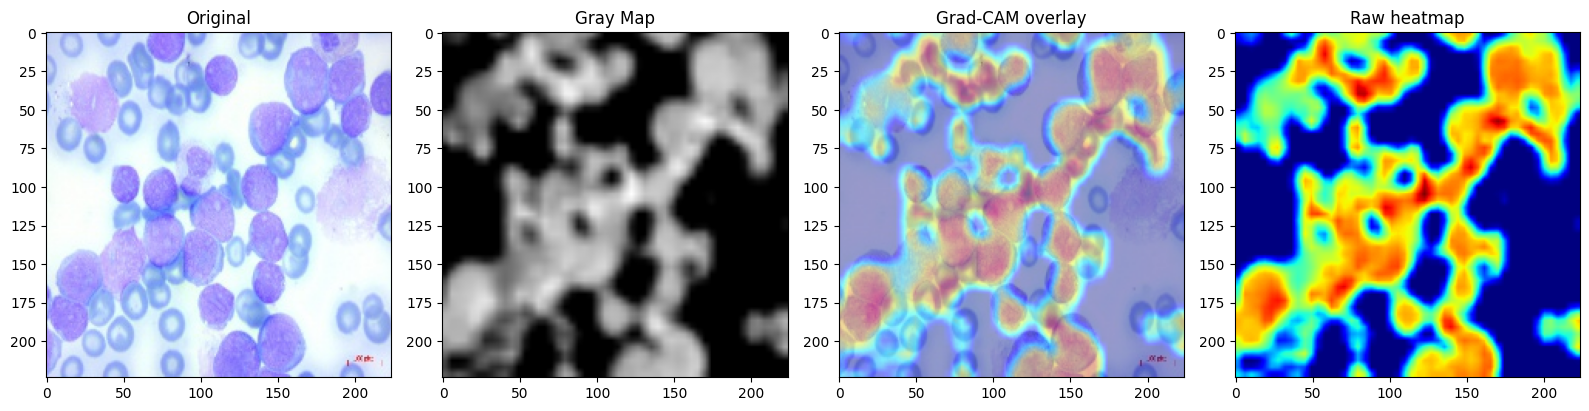

True label: 1
Raw prediction: 0.9999995
Rounded result: 1.0
Index: 321

Pipeline 1 results with seed = 43
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9648 - loss: 0.0858
Accuracy: 0.9648351669311523
TN: 87
FP: 16
FN: 0
TP: 352
Overall Accuracy: 0.965

Benign Stats
Precision: 1.000
Recall: 0.845
F1: 0.916

Malignant Stats
Precision: 0.957
Recall: 1.000
F1: 0.978

Displaying one sample image


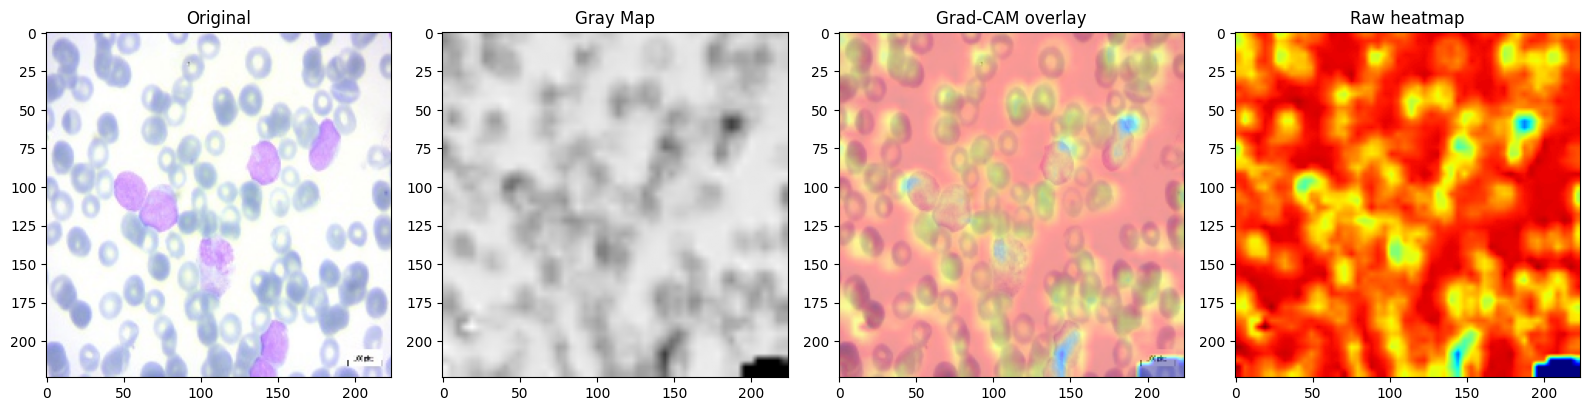

True label: 1
Raw prediction: 0.9918493
Rounded result: 1.0
Index: 53

Pipeline 1 results with seed = 44
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9626 - loss: 0.1008
Accuracy: 0.9626373648643494
TN: 84
FP: 11
FN: 6
TP: 354
Overall Accuracy: 0.963

Benign Stats
Precision: 0.933
Recall: 0.884
F1: 0.908

Malignant Stats
Precision: 0.970
Recall: 0.983
F1: 0.977

Displaying one sample image


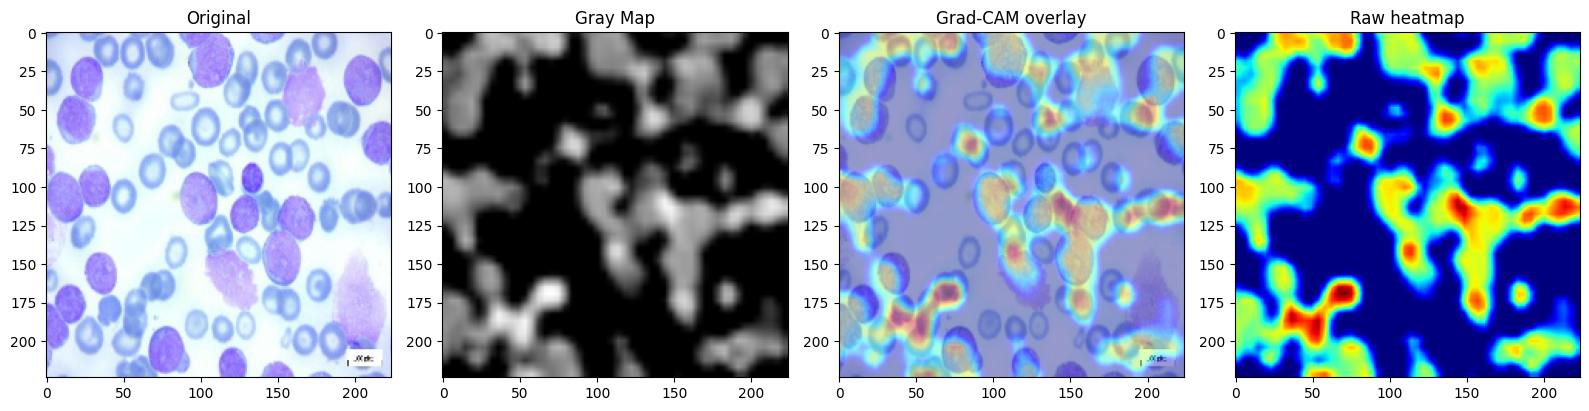

True label: 1
Raw prediction: 0.9481798
Rounded result: 1.0
Index: 418

Pipeline 1 results with seed = 45
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9582 - loss: 0.1189
Accuracy: 0.9582417607307434
TN: 95
FP: 16
FN: 3
TP: 341
Overall Accuracy: 0.958

Benign Stats
Precision: 0.969
Recall: 0.856
F1: 0.909

Malignant Stats
Precision: 0.955
Recall: 0.991
F1: 0.973

Displaying one sample image


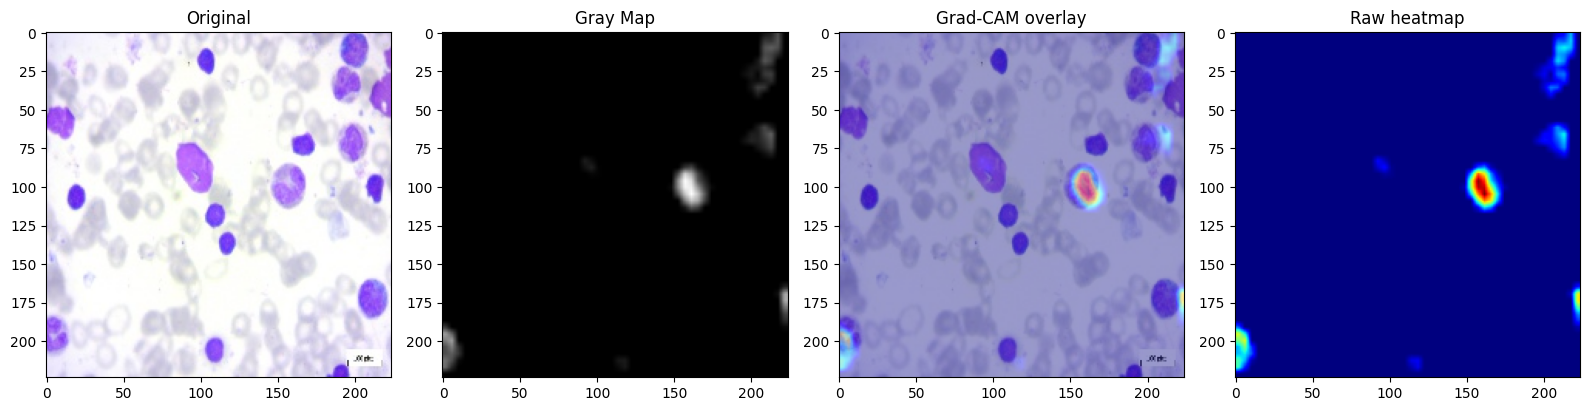

True label: 0
Raw prediction: 0.0022483785
Rounded result: 0.0
Index: 36

Pipeline 1 results with seed = 46
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9626 - loss: 0.1015
Accuracy: 0.9626373648643494
TN: 94
FP: 11
FN: 6
TP: 344
Overall Accuracy: 0.963

Benign Stats
Precision: 0.940
Recall: 0.895
F1: 0.917

Malignant Stats
Precision: 0.969
Recall: 0.983
F1: 0.976

Displaying one sample image


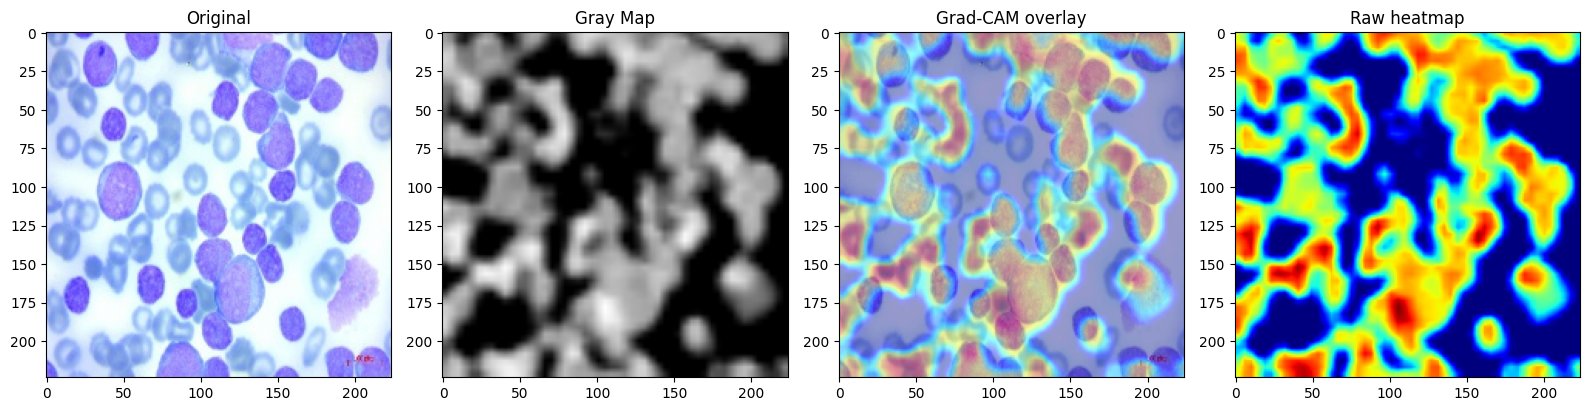

True label: 1
Raw prediction: 0.9999999
Rounded result: 1.0
Index: 176

Pipeline 1 results with seed = 47
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9429 - loss: 0.1726
Accuracy: 0.9428571462631226
TN: 84
FP: 14
FN: 12
TP: 345
Overall Accuracy: 0.943

Benign Stats
Precision: 0.875
Recall: 0.857
F1: 0.866

Malignant Stats
Precision: 0.961
Recall: 0.966
F1: 0.964

Displaying one sample image


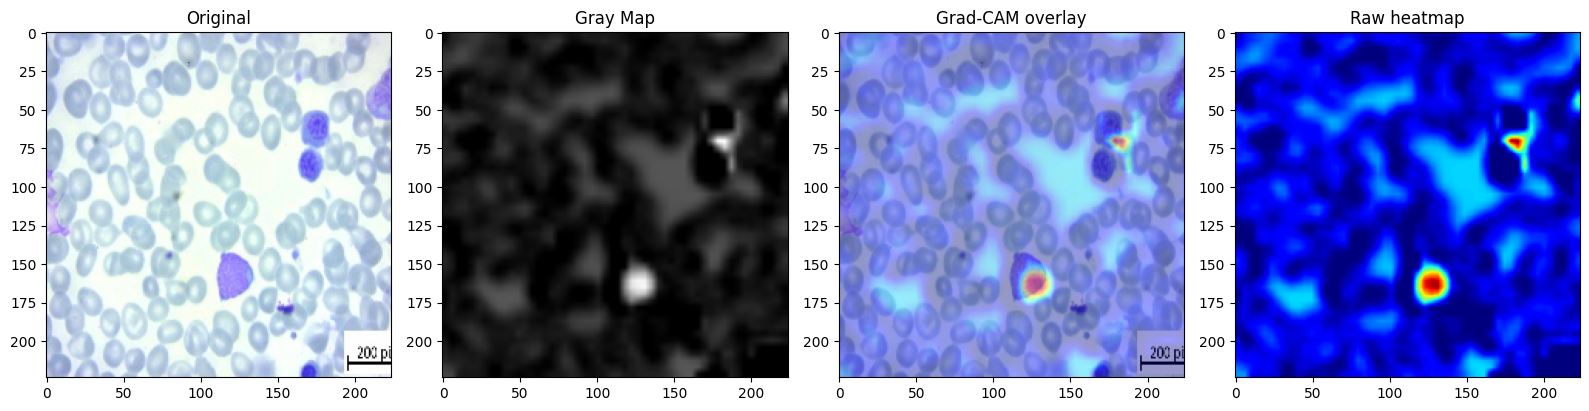

True label: 0
Raw prediction: 3.2585092e-05
Rounded result: 0.0
Index: 305

Pipeline 1 results with seed = 48
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9670 - loss: 0.0878
Accuracy: 0.9670329689979553
TN: 85
FP: 11
FN: 4
TP: 355
Overall Accuracy: 0.967

Benign Stats
Precision: 0.955
Recall: 0.885
F1: 0.919

Malignant Stats
Precision: 0.970
Recall: 0.989
F1: 0.979

Displaying one sample image


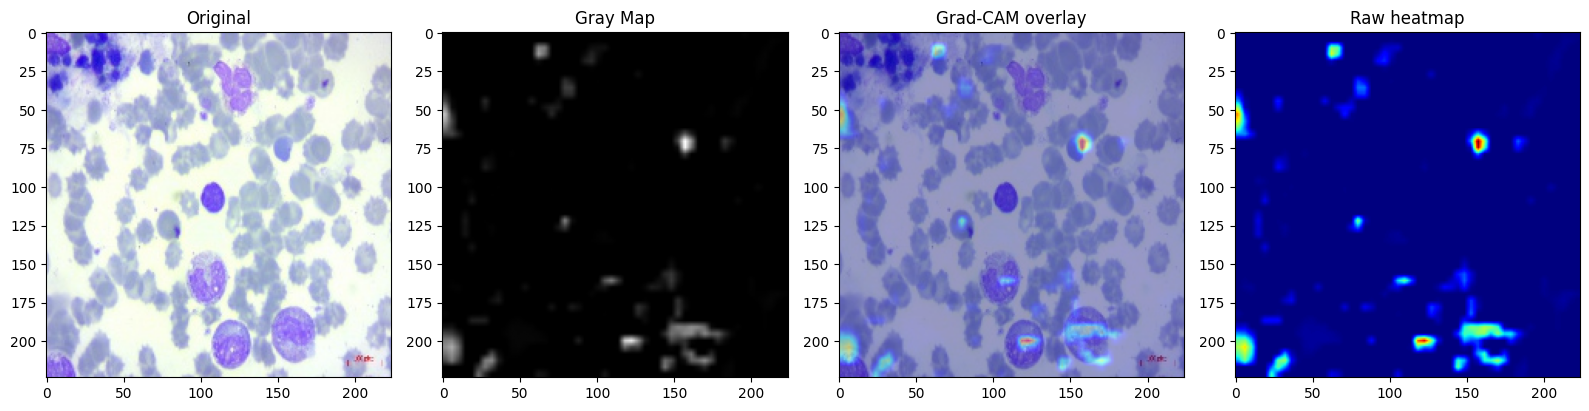

True label: 0
Raw prediction: 0.79053116
Rounded result: 1.0
Index: 201

Pipeline 1 results with seed = 49
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9648 - loss: 0.1188
Accuracy: 0.9648351669311523
TN: 84
FP: 15
FN: 1
TP: 355
Overall Accuracy: 0.965

Benign Stats
Precision: 0.988
Recall: 0.848
F1: 0.913

Malignant Stats
Precision: 0.959
Recall: 0.997
F1: 0.978

Displaying one sample image


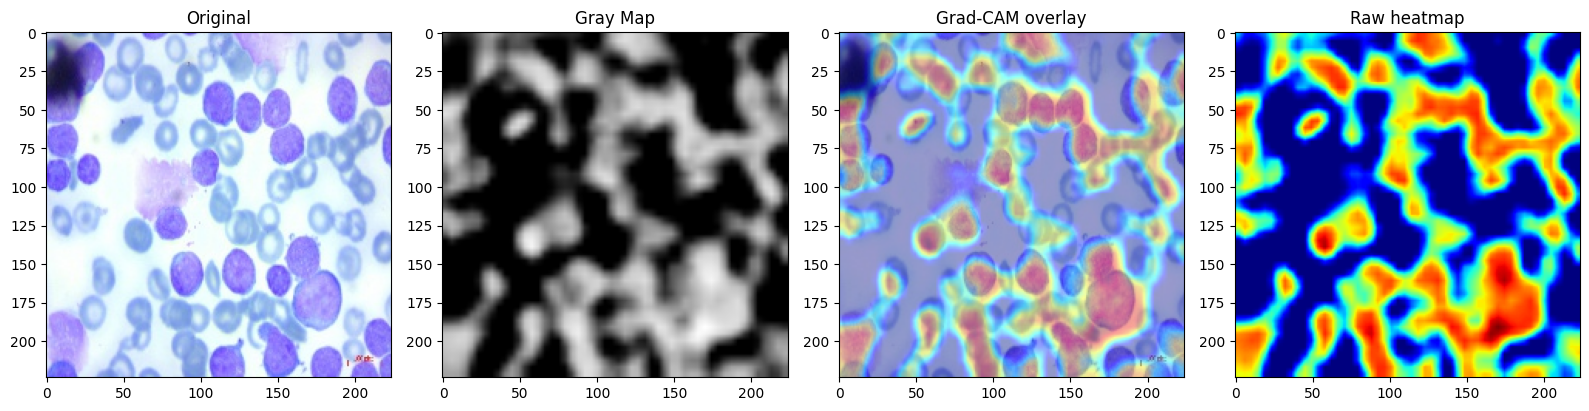

True label: 1
Raw prediction: 1.0
Rounded result: 1.0
Index: 40

Pipeline 1 results with seed = 50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9516 - loss: 0.1119
Accuracy: 0.9516483545303345
TN: 101
FP: 12
FN: 10
TP: 332
Overall Accuracy: 0.952

Benign Stats
Precision: 0.910
Recall: 0.894
F1: 0.902

Malignant Stats
Precision: 0.965
Recall: 0.971
F1: 0.968

Displaying one sample image


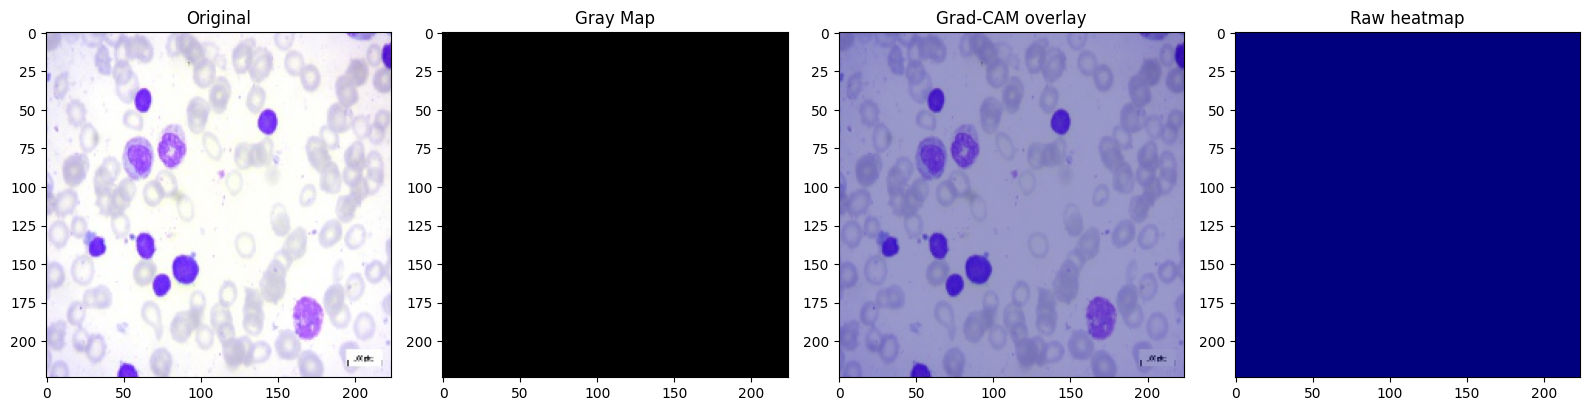

True label: 0
Raw prediction: 1.2874585e-05
Rounded result: 0.0
Index: 453

Pipeline 1 results with seed = 51
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9714 - loss: 0.1144
Accuracy: 0.9714285731315613
TN: 94
FP: 8
FN: 5
TP: 348
Overall Accuracy: 0.971

Benign Stats
Precision: 0.949
Recall: 0.922
F1: 0.935

Malignant Stats
Precision: 0.978
Recall: 0.986
F1: 0.982

Displaying one sample image


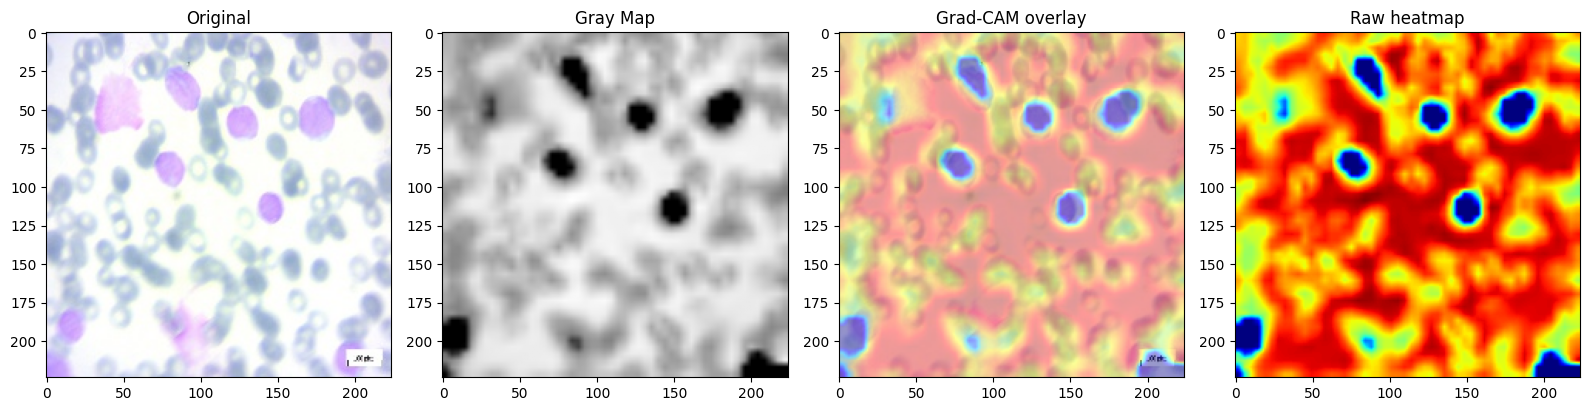

True label: 1
Raw prediction: 0.9937995
Rounded result: 1.0
Index: 181

| PIPELINE 2 |


In [ ]:
#Main Program

images_list, labels_list, filenames_list = load_data()
seeds = [42,43,44,45,46,47,48,49,50,51]

#PIPELINE 1
print('| PIPELINE 1 |')
for seed in seeds:
  np.random.seed(seed)
  tf.random.set_seed(seed)

  x_train, y_train, x_test, y_test, class_weights = traintest_classweight_normalize(images_list, labels_list,seed)
  model = train_model(x_train, y_train, class_weights)
  print(f'Pipeline 1 results with seed = {seed}')
  evaluate_model(model, x_test, y_test)

  random_grad_idx = random.randint(0, len(x_test) - 1)

  heatmap = grad_cam(model, x_test, random_grad_idx)
  display_visual(heatmap, random_grad_idx, x_test, y_test, model)

#PIPELINE 2:
print('| PIPELINE 2 |')
converted_images = preprocess(images_list)

for seed in seeds:
  np.random.seed(seed)
  tf.random.set_seed(seed)

  x_train, y_train, x_test, y_test, class_weights = traintest_classweight_normalize(converted_images, labels_list, seed)
  model = train_model(x_train, y_train, class_weights)
  print(f'Pipeline 2 results with seed = {seed}')
  evaluate_model(model, x_test, y_test)

  random_grad_idx = random.randint(0, len(x_test) - 1)

  heatmap = grad_cam(model, x_test, random_grad_idx)
  display_visual(heatmap, random_grad_idx, x_test, y_test, model)


In [ ]:
#DEMO PREDICTION
random_grad_idx = random.randint(0, len(x_test) - 1)
display_visual(heatmap, random_grad_idx, x_test, y_test, model)

answer = input('Would you like to try again with another image? (yes/no)')
while answer == 'yes':
  random_grad_idx = random.randint(0, len(x_test) - 1)
  heatmap = grad_cam(model, x_test, random_grad_idx)
  display_visual(heatmap, random_grad_idx, x_test, y_test, model)
  answer = input('Would you like to try again with another image? (yes/no)')